In [37]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
import os
import tqdm
import functools
import sys

import pandas as pd

import matplotlib.pyplot as plt

import numpy as np

import tensorflow as tf
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

In [ ]:
from discovery import collect_vep, load_panel, PROTEIN_AFFECTING_SET

In [40]:
# path with mutations
base_folder = "/data/bbg/nobackup/prominent/chip"
deepCSA_run = '2026-04-14'
deepCSA_folder = f'{base_folder}/deepCSA/runs/{deepCSA_run}_deepCSA/{deepCSA_run}_CH_I_wSP_filtered_muts'
sample_group = 'CohortCha_TimepointT0'
impact = 'protein_affecting'
output_folder = f'{base_folder}/analysis/{deepCSA_run}_deepCSA_CH_I_wSP/{deepCSA_run}_CH_I_wSP_custom_analysis/saturation_mutagenesis/saturation_kinetics/plots/{sample_group}/'
os.makedirs(output_folder, exist_ok=True)

# load mutations

In [41]:
mutations_genomic = pd.read_csv(f'{base_folder}/analysis/{deepCSA_run}_deepCSA_CH_I_wSP/{deepCSA_run}_CH_I_wSP_custom_analysis/saturation_mutagenesis/saturation_kinetics/{sample_group}_mutations_genomic_rates.{impact}.tsv', sep='\t')
mutations_residue = pd.read_csv(f'{base_folder}/analysis/{deepCSA_run}_deepCSA_CH_I_wSP/{deepCSA_run}_CH_I_wSP_custom_analysis/saturation_mutagenesis/saturation_kinetics/{sample_group}_mutations_residue_rates.{impact}.tsv', sep='\t')

In [42]:
mutations_genomic.head()

,GENE,POS,ALT_DEPTH,DEPTH,UNIQUE_RATE_0,UNIQUE_RATE_1,UNIQUE_RATE_2,UNIQUE_RATE_3,UNIQUE_RATE_4,UNIQUE_RATE_5,...,UNIQUE_RATE_10,UNIQUE_RATE_11,UNIQUE_RATE_12,UNIQUE_RATE_13,UNIQUE_RATE_14,UNIQUE_RATE_15,UNIQUE_RATE_16,UNIQUE_RATE_17,UNIQUE_RATE_18,UNIQUE_RATE_19
0,ADGRA3,22387709,1,851098.0,0.009999,0.012672,0.016058,0.020349,0.025788,0.032679,...,0.106794,0.135332,0.171497,0.217326,0.275402,0.348997,0.442259,0.560444,0.710211,0.900000
1,ADGRA3,22387715,1,865477.0,0.009999,0.012672,0.016058,0.020349,0.025788,0.032679,...,0.106794,0.135332,0.171497,0.217326,0.275402,0.348997,0.442260,0.560445,0.710211,0.900000
2,ADGRA3,22387719,7,861087.0,0.067928,0.085397,0.107131,0.134042,0.167131,0.207507,...,0.546414,0.638638,0.732049,0.820087,0.895124,0.950447,0.983211,0.996830,0.999828,1.000000
3,ADGRA3,22387721,2,866265.0,0.019899,0.025183,0.031859,0.040285,0.050910,0.064291,...,0.202183,0.252351,0.313583,0.387422,0.474958,0.576196,0.688926,0.806791,0.916023,0.990000
4,ADGRA3,22387727,1,889793.0,0.009999,0.012671,0.016058,0.020350,0.025788,0.032678,...,0.106793,0.135333,0.171497,0.217326,0.275402,0.348998,0.442260,0.560444,0.710211,0.899999


In [43]:
mutations_residue.head()

,GENE,RESIDUE,ALT_DEPTH,DEPTH,UNIQUE_RATE_0,UNIQUE_RATE_1,UNIQUE_RATE_2,UNIQUE_RATE_3,UNIQUE_RATE_4,UNIQUE_RATE_5,...,UNIQUE_RATE_10,UNIQUE_RATE_11,UNIQUE_RATE_12,UNIQUE_RATE_13,UNIQUE_RATE_14,UNIQUE_RATE_15,UNIQUE_RATE_16,UNIQUE_RATE_17,UNIQUE_RATE_18,UNIQUE_RATE_19
0,ADGRA3,A1033,1,844699.0,0.009999,0.012672,0.016058,0.020349,0.025788,0.032679,...,0.106794,0.135332,0.171497,0.217326,0.275402,0.348998,0.442259,0.560445,0.710210,0.900000
1,ADGRA3,A1094,1,865388.0,0.009999,0.012672,0.016058,0.020349,0.025787,0.032679,...,0.106794,0.135332,0.171498,0.217327,0.275402,0.348997,0.442259,0.560445,0.710211,0.900000
2,ADGRA3,A1103,26,920693.0,0.229939,0.282212,0.343555,0.414074,0.493013,0.578464,...,0.946944,0.977194,0.992490,0.998290,0.999770,0.999986,1.000000,1.000000,1.000000,1.000000
3,ADGRA3,A1120,1,902829.0,0.010000,0.012671,0.016058,0.020349,0.025788,0.032678,...,0.106794,0.135332,0.171498,0.217326,0.275402,0.348997,0.442260,0.560444,0.710211,0.900000
4,ADGRA3,A1121,1,901322.0,0.010000,0.012671,0.016059,0.020349,0.025788,0.032679,...,0.106794,0.135332,0.171497,0.217326,0.275402,0.348997,0.442259,0.560445,0.710211,0.899999


# compute empirical discovery index curves per gene

In [44]:
vep = collect_vep(deepCSA_folder)
df_panel = load_panel(deepCSA_folder, sample_group, vep)


In [45]:
# df_panel represents the total number of mutable sites,
# either genomic or residue sites
print(df_panel.shape)
if impact == "protein_affecting":
    df_panel = df_panel[df_panel["IMPACT"].isin(PROTEIN_AFFECTING_SET)]
else:
    df_panel = df_panel[df_panel["IMPACT"] == "synonymous"]
    
print(df_panel.shape)

(151239, 12)
(117546, 12)


In [46]:
df_panel_genomic = df_panel.groupby(['POS', 'GENE']).agg({'DEPTH': 'mean'}).reset_index()
df_panel_residue = df_panel.groupby(['RESIDUE',  'GENE']).agg({'DEPTH': 'mean'}).reset_index()

In [47]:
df_panel_dict = {
    'genomic': df_panel_genomic,
    'residue': df_panel_residue
    }

mutations_dict = {
    'genomic': mutations_genomic,
    'residue': mutations_residue
}

In [48]:
subsampling_rates = np.logspace(-2, np.log10(0.9), num=20)

def empirical_discovery_index_curve(gene, replicates=100, sites='genomic'):

    df = mutations_dict[sites]
    df = df[df['GENE'] == gene]

    dg = df_panel_dict[sites]
    dg = dg[dg['GENE'] == gene]

    size = dg.shape[0]
    mean_depth = df['DEPTH'].mean()
    
    x, mean, err_low, err_high = [], [], [], []
    
    unique_dict = {}
    for i, p in tqdm.tqdm(enumerate(subsampling_rates)):
        dist_bernoulli = tfd.Bernoulli(probs=df[f'UNIQUE_RATE_{i}'].values)
        unique_mutations = np.sum(dist_bernoulli.sample(sample_shape=(100,)), axis=1)
        y = list(unique_mutations / size)
        mean += [np.mean(y)]
        err_low += [np.percentile(y, 2.5)]
        err_high += [np.percentile(y, 97.5)]
        x += [mean_depth * p]
    mean += [df.shape[0] / size]
    err_low += [df.shape[0] / size]
    err_high += [df.shape[0] / size]
    x += [mean_depth]

    return x, mean, err_low, err_high

In [49]:
def plot_empirical_discovery(gene):
    x, mean, err_low, err_high = empirical_discovery_index_curve(gene, sites='genomic')
    plt.scatter(x, mean, s=50)
    for i, m in enumerate(x):
        plt.vlines(m, err_low[i], err_high[i])
    plt.xscale('log')
    plt.title(gene)
    plt.show()

20it [00:00, 349.34it/s]


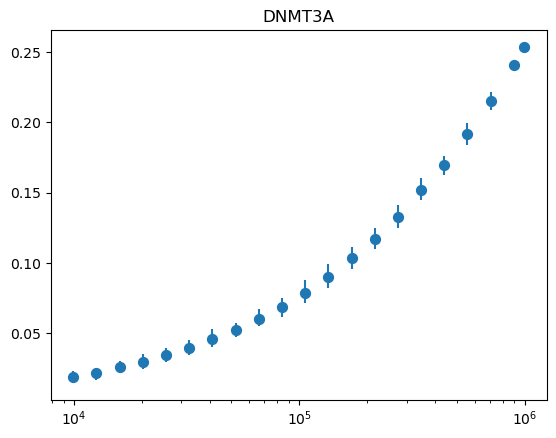

In [50]:
plot_empirical_discovery('DNMT3A')

# theoretical neutral vs empirical discovery curves

In [51]:
# Create a PDF to save the plots
def main_empirical(sample, sites='genomic', impact = "protein_affecting", logscale=False, genes_list = None):

    mutations_lite = mutations_dict[sites]
    mutations_lite['VAF'] = mutations_lite.apply(lambda r: r['ALT_DEPTH']/r['DEPTH'], axis=1)

    df_panel = pd.read_csv(os.path.join(deepCSA_folder, 'regions', 'consensuspanels', 'consensus.exons_splice_sites.tsv'), sep='\t')

    # include depth per site

    df_depth = pd.read_csv(os.path.join(deepCSA_folder, 'depths', 'individual',f'{sample}.depths.annotated.tsv.gz'), sep='\t')
    df_panel = pd.merge(df_panel, df_depth[['CHROM', 'POS', sample]], on=['CHROM', 'POS'], how='left')
    df_panel.rename(columns={sample: 'DEPTH'}, inplace=True)

    # retrieve relative mutability
    mutability_raw = pd.read_csv(os.path.join(deepCSA_folder, 'processing_files', 'absolutemutabilities', f'mutabilities_per_site.{sample}.tsv.gz'), 
                                    sep='\t')

    mutability_raw = pd.merge(mutability_raw, df_panel, on=['CHROM', 'POS', 'CONTEXT_MUT', 'GENE','IMPACT'], how='left')
    mutability_raw = mutability_raw.rename(columns={sample: "MUTABILITY"})
    # collect VEP annotations

    df_panel = pd.merge(df_panel, vep[['CHROM', 'POS', 'REF', 'ALT', 'AACHANGE', 'GENE']], 
                              left_on=['CHROM', 'POS', 'REF', 'ALT', 'GENE'], 
                              right_on=['CHROM', 'POS', 'REF', 'ALT', 'GENE'],
                              how='left')

    if genes_list is None:
        genes_list = df_panel['GENE'].unique()

    for gene in tqdm.tqdm(genes_list):

        try:
            synonymous_mutation_rate = pd.read_csv(os.path.join(deepCSA_folder, 'selection','omega', 'preprocessing', f'mutability_per_sample_gene_context.{sample}.tsv'), sep='\t')
            synonymous_mutation_rate = synonymous_mutation_rate[synonymous_mutation_rate['GENE'] == gene]
            mutability_gene = mutability_raw[mutability_raw['GENE'] == gene]
            mutability_gene = pd.merge(mutability_gene, synonymous_mutation_rate[['CONTEXT_MUT', sample]], on=['CONTEXT_MUT'], how='left')
            mutability_gene.rename(columns={sample: 'MUTRATE'}, inplace=True)

            mutability_gene = pd.merge(mutability_gene, df_panel[['CHROM', 'POS', 'REF', 'ALT', 'AACHANGE']], on=['CHROM', 'POS', 'REF', 'ALT'], how='left')

            # discard positions in non-CDS regions, probably splicing and intronic
            mutability_gene = mutability_gene[(mutability_gene['AACHANGE'] != '-') & (~mutability_gene['AACHANGE'].isnull())]

            # keep only protein affecting mutation sites
            if impact == "protein_affecting":
                mutability_gene = mutability_gene[mutability_gene["IMPACT"].isin(PROTEIN_AFFECTING_SET)]
            else:
                mutability_gene = mutability_gene[mutability_gene["IMPACT"] == 'synonymous']

            mutability_gene['RESIDUE'] = mutability_gene['AACHANGE'].apply(lambda s: s[:-1])
            print(mutability_gene.head())
            if sites == 'residue':
                mutability_gene = mutability_gene.groupby(['GENE', 'RESIDUE']).agg({'MUTRATE': 'sum', 'DEPTH': 'mean'}).reset_index()
            elif sites == 'genomic':
                mutability_gene = mutability_gene.groupby(['GENE', 'POS']).agg({'MUTRATE': 'sum', 'DEPTH': 'mean'}).reset_index()
            
            mutability_gene['MUTABILITY'] = mutability_gene.apply(lambda s: (s['MUTRATE'] / s['DEPTH']), axis=1)

            if sites == 'residue':
                mutability_gene = pd.merge(mutability_gene, mutations_lite[['GENE', 'RESIDUE', 'VAF']], on=['GENE', 'RESIDUE'], how='left')
            elif sites == 'genomic':
                mutability_gene = pd.merge(mutability_gene, mutations_lite[['GENE', 'POS', 'VAF']], on=['GENE', 'POS'], how='left')


            # neutral rate
            mutability_gene['RATE_NEUTRAL'] = mutability_gene['MUTABILITY']
            total_neutral_rate = mutability_gene['RATE_NEUTRAL'].sum()

            # compute saturation theoretical
            y_unique_neutral = []
            if sites == 'genomic':
                x_theoretical = np.logspace(3, 8, num=100)
            elif sites == 'residue':
                x_theoretical = np.logspace(3, 7, num=100)

            for depth in x_theoretical:
                unique_neutral = np.sum(1 - np.exp(-mutability_gene['RATE_NEUTRAL'].values * depth)) / mutability_gene.shape[0]
                y_unique_neutral.append(unique_neutral)

            # compute empirical discovery index curve

            x_empirical, mean, err_low, err_high = empirical_discovery_index_curve(gene, sites=sites)
            # plot

            fig, ax1 = plt.subplots(figsize=(2,2))
            ax1.set_xscale('log')
            if logscale:
                ax1.set_yscale('log')

            # empirical

            ax1.scatter(x_empirical[:-1], mean[:-1], label='downsampling', color='brown', s=5)
            ax1.scatter(x_empirical[-1], mean[-1], label='observed', color='white', edgecolors='brown', alpha=1, s=100)
            for i, m in enumerate(x_empirical[:-2]):
                plt.vlines(m, err_low[i], err_high[i], color='brown', lw=1)

            # theoretical

            ax1.plot(x_theoretical, y_unique_neutral, color='grey', lw=2, label='neutral theoretical', alpha=0.5)  # neutral
            # ax1.tick_params(axis='y', labelcolor=color)
            if sites == 'residue':
                ax1.set_ylabel('proportion of\nmutated residues')
            elif sites == 'genomic':
                ax1.set_ylabel('proportion of\nmutated nucleotides')
            
            ax1.set_xlabel('depth per residue')
            # ax1.vlines(5e5, 0, 1., linestyles='dashed', color='maroon', label='cohort', alpha=0.3)

            ax1.spines['top'].set_visible(False)
            ax1.spines['right'].set_visible(False)

            ax1.set_xlim(x_theoretical[0], x_theoretical[-1])

            # ax1.legend(loc=(1,0))

            plt.title(gene + " (" + impact + ")")

            if logscale:
                plt.savefig(f'{output_folder}/proportion_mutated_sites_{sites}_logscale_{gene}.{impact}.png', bbox_inches='tight', dpi=300)
                print(f"Plot saved to {output_folder}")
            else:
                plt.savefig(f'{output_folder}/proportion_mutated_sites_{sites}_{gene}.{impact}.png', bbox_inches='tight', dpi=300)
                print(f"Plot saved to {output_folder}")

            plt.show()

        except:

            print(gene)
            continue

  0%|          | 0/6 [00:00<?, ?it/s]

  CHROM       POS CONTEXT_MUT    GENE    IMPACT  MUTABILITY REF ALT  \
0  chr2  25234279       CTT>A  DNMT3A  nonsense    0.023702   T   A   
2  chr2  25234279       CTT>G  DNMT3A  nonsense    0.034094   T   G   
3  chr2  25234280       TTA>A  DNMT3A  nonsense    0.022400   T   A   
5  chr2  25234280       TTA>G  DNMT3A  nonsense    0.023968   T   G   
6  chr2  25234281       GTA>G  DNMT3A  nonsense    0.028000   A   C   

              MUT_ID CONTEXT     DEPTH   MUTRATE AACHANGE RESIDUE  
0  chr2_25234279_T/A     CTT  973915.0  0.023686    *913Y    *913  
2  chr2_25234279_T/G     CTT  973915.0  0.034071    *913Y    *913  
3  chr2_25234280_T/A     TTA  966112.0  0.022566    *913L    *913  
5  chr2_25234280_T/G     TTA  966112.0  0.024146    *913S    *913  
6  chr2_25234281_A/C     GTA  961671.0  0.028337    *913E    *913  



20it [00:00, 347.81it/s]


Plot saved to /data/bbg/nobackup/prominent/chip/analysis/2026-04-14_deepCSA_CH_I_wSP/2026-04-14_CH_I_wSP_custom_analysis/saturation_mutagenesis/saturation_kinetics/plots/CohortCha_TimepointT0/


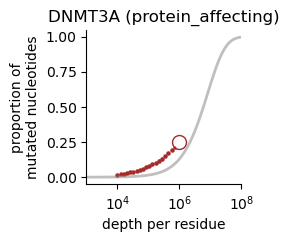

 17%|█▋        | 1/6 [00:00<00:02,  1.86it/s]

   CHROM        POS CONTEXT_MUT  GENE    IMPACT  MUTABILITY REF ALT  \
60  chr4  105233943       ATC>G  TET2  nonsense    0.011305   A   C   
61  chr4  105233943       ATC>C  TET2  nonsense    0.041041   A   G   
62  chr4  105233943       ATC>A  TET2  nonsense    0.033177   A   T   
63  chr4  105233944       ATG>A  TET2  nonsense    0.023081   T   A   
64  chr4  105233944       ATG>C  TET2  nonsense    0.063518   T   C   

                MUT_ID CONTEXT      DEPTH   MUTRATE AACHANGE RESIDUE  
60  chr4_105233943_A/C     ATC  1139002.0  0.011271      M1L      M1  
61  chr4_105233943_A/G     ATC  1139002.0  0.040920      M1V      M1  
62  chr4_105233943_A/T     ATC  1139002.0  0.033079      M1L      M1  
63  chr4_105233944_T/A     ATG  1147650.0  0.022840      M1K      M1  
64  chr4_105233944_T/C     ATG  1147650.0  0.062854      M1T      M1  



20it [00:00, 339.86it/s]


Plot saved to /data/bbg/nobackup/prominent/chip/analysis/2026-04-14_deepCSA_CH_I_wSP/2026-04-14_CH_I_wSP_custom_analysis/saturation_mutagenesis/saturation_kinetics/plots/CohortCha_TimepointT0/


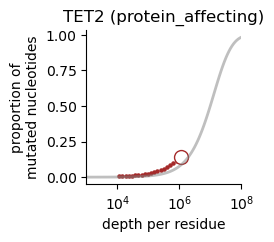

 33%|███▎      | 2/6 [00:01<00:02,  1.81it/s]

   CHROM       POS CONTEXT_MUT   GENE    IMPACT  MUTABILITY REF ALT  \
0  chr17  60600415       ATG>G  PPM1D  nonsense    0.005295   A   C   
1  chr17  60600415       ATG>C  PPM1D  nonsense    0.024098   A   G   
2  chr17  60600415       ATG>A  PPM1D  nonsense    0.008757   A   T   
3  chr17  60600416       ATG>A  PPM1D  nonsense    0.008797   T   A   
4  chr17  60600416       ATG>C  PPM1D  nonsense    0.024210   T   C   

               MUT_ID CONTEXT     DEPTH   MUTRATE AACHANGE RESIDUE  
0  chr17_60600415_A/C     ATG  612177.0  0.008135      M1L      M1  
1  chr17_60600415_A/G     ATG  612177.0  0.037025      M1V      M1  
2  chr17_60600415_A/T     ATG  612177.0  0.013454      M1L      M1  
3  chr17_60600416_T/A     ATG  615035.0  0.013454      M1K      M1  
4  chr17_60600416_T/C     ATG  615035.0  0.037025      M1T      M1  



20it [00:00, 397.15it/s]


Plot saved to /data/bbg/nobackup/prominent/chip/analysis/2026-04-14_deepCSA_CH_I_wSP/2026-04-14_CH_I_wSP_custom_analysis/saturation_mutagenesis/saturation_kinetics/plots/CohortCha_TimepointT0/


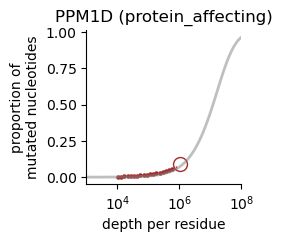

 50%|█████     | 3/6 [00:01<00:01,  1.86it/s]

   CHROM      POS CONTEXT_MUT  GENE    IMPACT  MUTABILITY REF ALT  \
0  chr17  7669609       GTC>A  TP53  nonsense    0.017535   T   A   
1  chr17  7669609       GTC>C  TP53  nonsense    0.028649   T   C   
2  chr17  7669609       GTC>G  TP53  nonsense    0.012102   T   G   
3  chr17  7669610       TCA>A  TP53  nonsense    0.033982   C   A   
4  chr17  7669610       TCA>G  TP53  nonsense    0.019599   C   G   

              MUT_ID CONTEXT      DEPTH   MUTRATE AACHANGE RESIDUE  
0  chr17_7669609_T/A     GTC  1030116.0  0.017204    *394C    *394  
1  chr17_7669609_T/C     GTC  1030116.0  0.028109    *394W    *394  
2  chr17_7669609_T/G     GTC  1030116.0  0.011873    *394C    *394  
3  chr17_7669610_C/A     TCA  1028643.0  0.033388    *394L    *394  
4  chr17_7669610_C/G     TCA  1028643.0  0.019257    *394S    *394  



20it [00:00, 394.14it/s]


Plot saved to /data/bbg/nobackup/prominent/chip/analysis/2026-04-14_deepCSA_CH_I_wSP/2026-04-14_CH_I_wSP_custom_analysis/saturation_mutagenesis/saturation_kinetics/plots/CohortCha_TimepointT0/


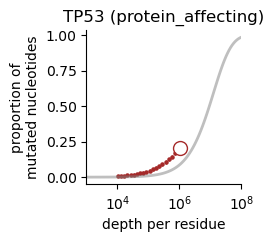

 67%|██████▋   | 4/6 [00:02<00:01,  1.89it/s]

    CHROM       POS CONTEXT_MUT   GENE    IMPACT  MUTABILITY REF ALT  \
24  chr22  28696901       CCT>A  CHEK2  missense    0.027927   C   A   
25  chr22  28696901       CCT>G  CHEK2  missense    0.028828   C   G   
27  chr22  28696902       CTT>A  CHEK2  missense    0.020992   T   A   
28  chr22  28696902       CTT>C  CHEK2  missense    0.032456   T   C   
29  chr22  28696902       CTT>G  CHEK2  missense    0.030196   T   G   

                MUT_ID CONTEXT     DEPTH   MUTRATE AACHANGE RESIDUE  
24  chr22_28696901_C/A     CCT  934410.0  0.030158    K365N    K365  
25  chr22_28696901_C/G     CCT  934410.0  0.031131    K365N    K365  
27  chr22_28696902_T/A     CTT  944690.0  0.022422    K365M    K365  
28  chr22_28696902_T/C     CTT  944690.0  0.034668    K365R    K365  
29  chr22_28696902_T/G     CTT  944690.0  0.032253    K365T    K365  



20it [00:00, 394.06it/s]


Plot saved to /data/bbg/nobackup/prominent/chip/analysis/2026-04-14_deepCSA_CH_I_wSP/2026-04-14_CH_I_wSP_custom_analysis/saturation_mutagenesis/saturation_kinetics/plots/CohortCha_TimepointT0/


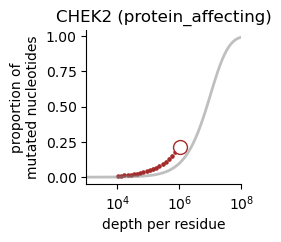

 83%|████████▎ | 5/6 [00:02<00:00,  1.91it/s]

   CHROM       POS CONTEXT_MUT   GENE    IMPACT  MUTABILITY REF ALT  \
0  chr20  32358776       ATC>G  ASXL1  nonsense    0.002226   A   C   
1  chr20  32358776       ATC>C  ASXL1  nonsense    0.008082   A   G   
2  chr20  32358776       ATC>A  ASXL1  nonsense    0.006533   A   T   
3  chr20  32358777       ATG>A  ASXL1  nonsense    0.004490   T   A   
4  chr20  32358777       ATG>C  ASXL1  nonsense    0.012356   T   C   

               MUT_ID CONTEXT     DEPTH   MUTRATE AACHANGE RESIDUE  
0  chr20_32358776_A/C     ATC  248549.0  0.010178      M1L      M1  
1  chr20_32358776_A/G     ATC  248549.0  0.036952      M1V      M1  
2  chr20_32358776_A/T     ATC  248549.0  0.029871      M1L      M1  
3  chr20_32358777_T/A     ATG  247380.0  0.020625      M1K      M1  
4  chr20_32358777_T/C     ATG  247380.0  0.056759      M1T      M1  



20it [00:00, 371.28it/s]


Plot saved to /data/bbg/nobackup/prominent/chip/analysis/2026-04-14_deepCSA_CH_I_wSP/2026-04-14_CH_I_wSP_custom_analysis/saturation_mutagenesis/saturation_kinetics/plots/CohortCha_TimepointT0/


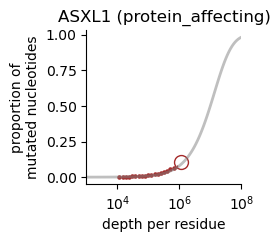

100%|██████████| 6/6 [00:03<00:00,  1.88it/s]


In [52]:
main_empirical('CohortCha_TimepointT0', sites='genomic', impact = impact, logscale=False, genes_list = ["DNMT3A","TET2","PPM1D","TP53","CHEK2","ASXL1"])

  0%|          | 0/6 [00:00<?, ?it/s]

  CHROM       POS CONTEXT_MUT    GENE    IMPACT  MUTABILITY REF ALT  \
0  chr2  25234279       CTT>A  DNMT3A  nonsense    0.023702   T   A   
2  chr2  25234279       CTT>G  DNMT3A  nonsense    0.034094   T   G   
3  chr2  25234280       TTA>A  DNMT3A  nonsense    0.022400   T   A   
5  chr2  25234280       TTA>G  DNMT3A  nonsense    0.023968   T   G   
6  chr2  25234281       GTA>G  DNMT3A  nonsense    0.028000   A   C   

              MUT_ID CONTEXT     DEPTH   MUTRATE AACHANGE RESIDUE  
0  chr2_25234279_T/A     CTT  973915.0  0.023686    *913Y    *913  
2  chr2_25234279_T/G     CTT  973915.0  0.034071    *913Y    *913  
3  chr2_25234280_T/A     TTA  966112.0  0.022566    *913L    *913  
5  chr2_25234280_T/G     TTA  966112.0  0.024146    *913S    *913  
6  chr2_25234281_A/C     GTA  961671.0  0.028337    *913E    *913  



20it [00:00, 360.36it/s]


Plot saved to /data/bbg/nobackup/prominent/chip/analysis/2026-04-14_deepCSA_CH_I_wSP/2026-04-14_CH_I_wSP_custom_analysis/saturation_mutagenesis/saturation_kinetics/plots/CohortCha_TimepointT0/


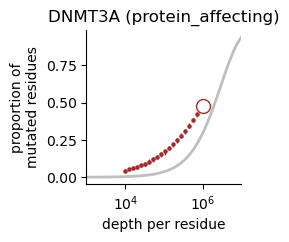

 17%|█▋        | 1/6 [00:00<00:02,  1.99it/s]

   CHROM        POS CONTEXT_MUT  GENE    IMPACT  MUTABILITY REF ALT  \
60  chr4  105233943       ATC>G  TET2  nonsense    0.011305   A   C   
61  chr4  105233943       ATC>C  TET2  nonsense    0.041041   A   G   
62  chr4  105233943       ATC>A  TET2  nonsense    0.033177   A   T   
63  chr4  105233944       ATG>A  TET2  nonsense    0.023081   T   A   
64  chr4  105233944       ATG>C  TET2  nonsense    0.063518   T   C   

                MUT_ID CONTEXT      DEPTH   MUTRATE AACHANGE RESIDUE  
60  chr4_105233943_A/C     ATC  1139002.0  0.011271      M1L      M1  
61  chr4_105233943_A/G     ATC  1139002.0  0.040920      M1V      M1  
62  chr4_105233943_A/T     ATC  1139002.0  0.033079      M1L      M1  
63  chr4_105233944_T/A     ATG  1147650.0  0.022840      M1K      M1  
64  chr4_105233944_T/C     ATG  1147650.0  0.062854      M1T      M1  



20it [00:00, 332.95it/s]


Plot saved to /data/bbg/nobackup/prominent/chip/analysis/2026-04-14_deepCSA_CH_I_wSP/2026-04-14_CH_I_wSP_custom_analysis/saturation_mutagenesis/saturation_kinetics/plots/CohortCha_TimepointT0/


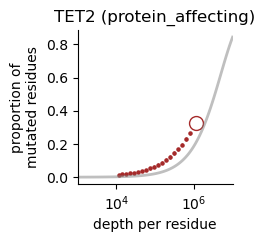

 33%|███▎      | 2/6 [00:01<00:02,  1.91it/s]

   CHROM       POS CONTEXT_MUT   GENE    IMPACT  MUTABILITY REF ALT  \
0  chr17  60600415       ATG>G  PPM1D  nonsense    0.005295   A   C   
1  chr17  60600415       ATG>C  PPM1D  nonsense    0.024098   A   G   
2  chr17  60600415       ATG>A  PPM1D  nonsense    0.008757   A   T   
3  chr17  60600416       ATG>A  PPM1D  nonsense    0.008797   T   A   
4  chr17  60600416       ATG>C  PPM1D  nonsense    0.024210   T   C   

               MUT_ID CONTEXT     DEPTH   MUTRATE AACHANGE RESIDUE  
0  chr17_60600415_A/C     ATG  612177.0  0.008135      M1L      M1  
1  chr17_60600415_A/G     ATG  612177.0  0.037025      M1V      M1  
2  chr17_60600415_A/T     ATG  612177.0  0.013454      M1L      M1  
3  chr17_60600416_T/A     ATG  615035.0  0.013454      M1K      M1  
4  chr17_60600416_T/C     ATG  615035.0  0.037025      M1T      M1  



20it [00:00, 401.80it/s]


Plot saved to /data/bbg/nobackup/prominent/chip/analysis/2026-04-14_deepCSA_CH_I_wSP/2026-04-14_CH_I_wSP_custom_analysis/saturation_mutagenesis/saturation_kinetics/plots/CohortCha_TimepointT0/


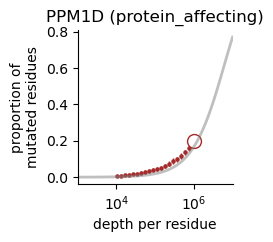

 50%|█████     | 3/6 [00:01<00:01,  1.95it/s]

   CHROM      POS CONTEXT_MUT  GENE    IMPACT  MUTABILITY REF ALT  \
0  chr17  7669609       GTC>A  TP53  nonsense    0.017535   T   A   
1  chr17  7669609       GTC>C  TP53  nonsense    0.028649   T   C   
2  chr17  7669609       GTC>G  TP53  nonsense    0.012102   T   G   
3  chr17  7669610       TCA>A  TP53  nonsense    0.033982   C   A   
4  chr17  7669610       TCA>G  TP53  nonsense    0.019599   C   G   

              MUT_ID CONTEXT      DEPTH   MUTRATE AACHANGE RESIDUE  
0  chr17_7669609_T/A     GTC  1030116.0  0.017204    *394C    *394  
1  chr17_7669609_T/C     GTC  1030116.0  0.028109    *394W    *394  
2  chr17_7669609_T/G     GTC  1030116.0  0.011873    *394C    *394  
3  chr17_7669610_C/A     TCA  1028643.0  0.033388    *394L    *394  
4  chr17_7669610_C/G     TCA  1028643.0  0.019257    *394S    *394  



20it [00:00, 400.65it/s]


Plot saved to /data/bbg/nobackup/prominent/chip/analysis/2026-04-14_deepCSA_CH_I_wSP/2026-04-14_CH_I_wSP_custom_analysis/saturation_mutagenesis/saturation_kinetics/plots/CohortCha_TimepointT0/


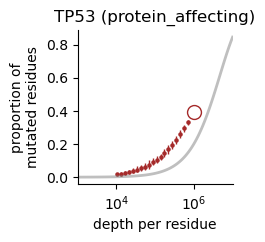

 67%|██████▋   | 4/6 [00:02<00:01,  1.98it/s]

    CHROM       POS CONTEXT_MUT   GENE    IMPACT  MUTABILITY REF ALT  \
24  chr22  28696901       CCT>A  CHEK2  missense    0.027927   C   A   
25  chr22  28696901       CCT>G  CHEK2  missense    0.028828   C   G   
27  chr22  28696902       CTT>A  CHEK2  missense    0.020992   T   A   
28  chr22  28696902       CTT>C  CHEK2  missense    0.032456   T   C   
29  chr22  28696902       CTT>G  CHEK2  missense    0.030196   T   G   

                MUT_ID CONTEXT     DEPTH   MUTRATE AACHANGE RESIDUE  
24  chr22_28696901_C/A     CCT  934410.0  0.030158    K365N    K365  
25  chr22_28696901_C/G     CCT  934410.0  0.031131    K365N    K365  
27  chr22_28696902_T/A     CTT  944690.0  0.022422    K365M    K365  
28  chr22_28696902_T/C     CTT  944690.0  0.034668    K365R    K365  
29  chr22_28696902_T/G     CTT  944690.0  0.032253    K365T    K365  



20it [00:00, 402.44it/s]


Plot saved to /data/bbg/nobackup/prominent/chip/analysis/2026-04-14_deepCSA_CH_I_wSP/2026-04-14_CH_I_wSP_custom_analysis/saturation_mutagenesis/saturation_kinetics/plots/CohortCha_TimepointT0/


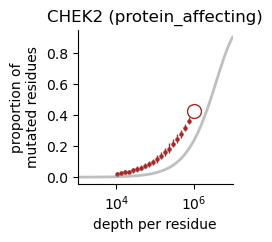

 83%|████████▎ | 5/6 [00:02<00:00,  2.00it/s]

   CHROM       POS CONTEXT_MUT   GENE    IMPACT  MUTABILITY REF ALT  \
0  chr20  32358776       ATC>G  ASXL1  nonsense    0.002226   A   C   
1  chr20  32358776       ATC>C  ASXL1  nonsense    0.008082   A   G   
2  chr20  32358776       ATC>A  ASXL1  nonsense    0.006533   A   T   
3  chr20  32358777       ATG>A  ASXL1  nonsense    0.004490   T   A   
4  chr20  32358777       ATG>C  ASXL1  nonsense    0.012356   T   C   

               MUT_ID CONTEXT     DEPTH   MUTRATE AACHANGE RESIDUE  
0  chr20_32358776_A/C     ATC  248549.0  0.010178      M1L      M1  
1  chr20_32358776_A/G     ATC  248549.0  0.036952      M1V      M1  
2  chr20_32358776_A/T     ATC  248549.0  0.029871      M1L      M1  
3  chr20_32358777_T/A     ATG  247380.0  0.020625      M1K      M1  
4  chr20_32358777_T/C     ATG  247380.0  0.056759      M1T      M1  



20it [00:00, 376.00it/s]


Plot saved to /data/bbg/nobackup/prominent/chip/analysis/2026-04-14_deepCSA_CH_I_wSP/2026-04-14_CH_I_wSP_custom_analysis/saturation_mutagenesis/saturation_kinetics/plots/CohortCha_TimepointT0/


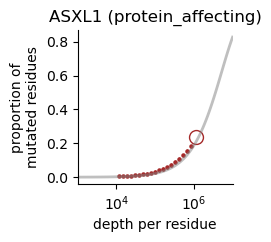

100%|██████████| 6/6 [00:03<00:00,  1.97it/s]


In [53]:
main_empirical('CohortCha_TimepointT0', sites='residue', impact=impact, logscale=False,genes_list = ["DNMT3A","TET2","PPM1D","TP53","CHEK2","ASXL1"])